# Exploración del top 20 de películas del grupo 2

**Parte:** Top 20 del grupo × dataset procesado (`movies` + `ratings` + `tags`)
**Notebook:** `group_20_movies.ipynb`

## 1. Introducción

Los notebooks de `notebooks/exploration/main/` caracterizan el dataset completo: el catálogo
(`movies.ipynb`), las calificaciones (`ratings.ipynb`), las etiquetas (`tags.ipynb`) y sus
combinaciones. Este notebook parte de esos resultados y responde una pregunta distinta:

> **¿Qué características y patrones presentan las 20 películas favoritas del grupo dentro del
> dataset procesado, y cómo se comparan con el resto del catálogo?**

El enfoque es **comparativo y posicional**: no se vuelve a describir el dataset global, sino que se
usa como línea base para ubicar nuestras 20 películas dentro de él. Las preguntas secundarias son:

1. ¿Qué tan bien valoradas están nuestras películas frente al catálogo? (§7.1)
2. ¿Qué tan populares son, medidas por volumen de calificaciones? (§7.2)
3. ¿Cómo se combinan calidad y popularidad? ¿Hay favoritas atípicas? (§7.3)
4. ¿Generan consenso o dividen a la audiencia? (§7.4)
5. ¿Qué géneros predominan y son buenas *dentro de su propio género*? (§7.5, §7.6)
6. ¿Qué patrón temporal tienen: año de estreno y evolución de su calificación? (§7.7, §7.8)
7. ¿Comparten audiencia entre sí? (§7.9)
8. ¿Qué otras películas del dataset prefieren los usuarios afines a nuestro gusto? (§7.10)
9. ¿Con qué vocabulario las describen los usuarios que las etiquetan? (§7.11)

**Origen de los datos.** Todas las cifras de este notebook se calculan sobre los CSV **procesados**
por el equipo (`data/processed/`), resultado de
`notebooks/presentation_cleaning/presentation_cleaning.ipynb`. No se usan los archivos crudos en
ningún punto: en particular, la cifra de 32,000,204 calificaciones que aparece en el README original
de `ml-32m` **no** corresponde a estos datos (tras la limpieza son 31,963,989).

## 2. Importación de librerías

In [1]:
import os
import sys

project_root = os.path.abspath('../../..')
sys.path.insert(0, os.path.join(project_root, 'src'))

from parcial_digd import utils_

In [2]:
import re
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', 60)

## 3. Carga del catálogo (`movies`)

Se carga primero solo el catálogo (4.5 MB) porque es lo que permite identificar los `movieId` de
nuestras 20 películas; ese conjunto de identificadores es necesario **antes** de tocar
`ratings.csv` (1.2 GB), de modo que ese archivo se recorra una sola vez (§5).

Se reutiliza `utils_.get_genre_columns()` (`src/parcial_digd/utils_.py`), la misma función que usan
los notebooks de `main/`, y se deriva `anio` igual que en `movies.ipynb` para que las cifras sean
comparables entre notebooks.

In [3]:
RUTA_MOVIES  = '../../../data/processed/movies.csv'
RUTA_RATINGS = '../../../data/processed/ratings.csv'
RUTA_TAGS    = '../../../data/processed/tags.csv'

movies = pd.read_csv(RUTA_MOVIES)
movies['release_year'] = pd.to_datetime(movies['release_year'])
movies['anio'] = movies['release_year'].dt.year

movies_gen = utils_.get_genre_columns(movies)   # 18 columnas binarias de género + 'None'
GENEROS = utils_.genres

print(f"Catálogo procesado: {movies.shape[0]:,} películas, "
      f"periodo {movies['anio'].min()}-{movies['anio'].max()}")
movies.head(3)

Catálogo procesado: 86,967 películas, periodo 1874-2023


,movieId,title,genres,release_year,anio
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995-01-01,1995
1,2,Jumanji,Adventure|Children|Fantasy,1995-01-01,1995
2,3,Grumpier Old Men,Comedy|Romance,1995-01-01,1995


## 4. Identificación de las 20 películas favoritas

**Qué se hace:** localizar el `movieId` de cada una de las 20 películas de la lista del grupo
(`Top_20_peliculas.pdf`) dentro del catálogo procesado.

**Por qué no es trivial:** los títulos de MovieLens no coinciden literalmente con los de la lista.
El catálogo pospone el artículo (`Truman Show, The`), incluye alias (`Men in Black (a.k.a. MIB)`),
títulos alternativos entre paréntesis
(`Fast and the Furious: Tokyo Drift, The (Fast and the Furious 3, The)`), subtítulos
(`Birdman: Or (The Unexpected Virtue of Ignorance)`) y caracteres especiales (`WALL·E`). Además hay
**títulos repetidos**: existen seis películas distintas llamadas `Venom`. Por eso el emparejamiento
se hace por **(título normalizado, año de estreno)** y nunca por título solo.

**Nota sobre la lista:** el PDF del grupo enumera 22 títulos. Se analizan los 20 primeros con dos
ajustes acordados: `Smile 2 (2024)` **no existe en el dataset** (la última calificación es de
octubre de 2023 y el catálogo llega hasta estrenos de 2023), por lo que se sustituye por
`The Amazing Spider-Man 2 (2014)`, que sí está presente. `Cars (2006)` queda fuera de las 20.

In [4]:
# (título tal como aparece en la lista del grupo, año de estreno)
TOP20_LISTA = [
    ("Grown Ups", 2010),
    ("Deadpool", 2016),
    ("Venom", 2018),
    ("The Truman Show", 1998),
    ("Chappie", 2015),
    ("WALL-E", 2008),
    ("Limitless", 2011),
    ("Fight Club", 1999),
    ("Interstellar", 2014),
    ("Birdman", 2014),
    ("I, Robot", 2004),
    ("The Hangover", 2009),
    ("Spider-Man", 2002),
    ("Men in Black", 1997),
    ("Alien", 1979),
    ("Predator", 1987),
    ("Terminator 2: Judgment Day", 1991),
    ("Fast and Furious: Tokyo Drift", 2006),
    ("Scary Movie", 2000),
    ("The Amazing Spider-Man 2", 2014),
]


def normalizar_titulo(titulo: str) -> str:
    """Lleva un título a una forma canónica comparable entre la lista del grupo y MovieLens."""
    t = str(titulo).lower()
    t = re.sub(r'\((?:a\.k\.a\.|aka)[^)]*\)', ' ', t)   # alias: "(a.k.a. MIB)"
    t = re.sub(r'\([^)]*\)', ' ', t)                    # títulos alternativos entre paréntesis
    t = t.replace('&', ' and ')
    m = re.match(r'^(.*),\s*(the|a|an)$', t.strip())    # "Truman Show, The" -> "the truman show"
    if m:
        t = f"{m.group(2)} {m.group(1)}"
    t = re.sub(r'[^a-z0-9]+', ' ', t)                   # puntuación y caracteres especiales (WALL·E)
    t = re.sub(r'\b(the|a|an)\b', ' ', t)               # el artículo no aporta al emparejamiento
    return re.sub(r'\s+', ' ', t).strip()


movies['title_norm'] = movies['title'].map(normalizar_titulo)

El emparejamiento se hace en dos etapas, y cada resultado queda registrado para poder auditarlo:

1. **Coincidencia exacta** de `(título normalizado, año)`.
2. **Respaldo por prefijo** para títulos con subtítulo añadido en MovieLens (caso `Birdman` →
   `Birdman: Or (The Unexpected Virtue of Ignorance)`), aceptado **solo si el candidato es único**.

Si alguna película quedara sin resolver o con más de un candidato, el `assert` final detiene el
notebook en lugar de continuar con un emparejamiento dudoso.

In [5]:
registro = []
for titulo, anio in TOP20_LISTA:
    objetivo = normalizar_titulo(titulo)
    del_anio = movies[movies['anio'] == anio]

    exactos = del_anio[del_anio['title_norm'] == objetivo]
    if len(exactos) == 1:
        etapa, candidatos = 'exacta', exactos
    else:
        etapa = 'prefijo'
        candidatos = del_anio[del_anio['title_norm'].str.startswith(objetivo + ' ')]

    registro.append({
        'lista': f"{titulo} ({anio})",
        'titulo_normalizado': objetivo,
        'etapa': etapa,
        'n_candidatos': len(candidatos),
        'movieId': candidatos['movieId'].iloc[0] if len(candidatos) == 1 else np.nan,
        'title_dataset': candidatos['title'].iloc[0] if len(candidatos) == 1 else '',
    })

correspondencia = pd.DataFrame(registro)
assert (correspondencia['n_candidatos'] == 1).all(), \
    correspondencia[correspondencia['n_candidatos'] != 1]
assert correspondencia['movieId'].nunique() == 20

FAV_IDS = correspondencia['movieId'].astype('int32').tolist()
correspondencia[['lista', 'etapa', 'movieId', 'title_dataset']]

,lista,etapa,movieId,title_dataset
0,Grown Ups (2010),exacta,79134,Grown Ups
1,Deadpool (2016),exacta,122904,Deadpool
2,Venom (2018),exacta,192389,Venom
3,The Truman Show (1998),exacta,1682,"Truman Show, The"
4,Chappie (2015),exacta,120466,Chappie
5,WALL-E (2008),exacta,60069,WALL·E
6,Limitless (2011),exacta,84152,Limitless
7,Fight Club (1999),exacta,2959,Fight Club
8,Interstellar (2014),exacta,109487,Interstellar
9,Birdman (2014),prefijo,112183,Birdman: Or (The Unexpected Virtue of Ignorance)


**Resultados:** las 20 películas quedan resueltas (19 por coincidencia exacta y `Birdman` por
prefijo). Los títulos del dataset confirman las particularidades anticipadas: `Truman Show, The`,
`Hangover, The`, `Men in Black (a.k.a. MIB)`, `Fast and the Furious: Tokyo Drift, The (...)`,
`WALL·E` y `Birdman: Or (The Unexpected Virtue of Ignorance)`.

La celda siguiente documenta por qué el año es indispensable: sin él, `Venom` y `Scary Movie` serían
ambiguos.

In [6]:
for t in ['venom', 'scary movie', 'birdman']:
    homonimas = movies[movies['title_norm'].str.startswith(t)][['movieId', 'title', 'anio', 'genres']]
    print(f"--- Coincidencias de '{t}' en el catálogo ({len(homonimas)}) ---")
    print(homonimas.sort_values('anio').to_string(index=False))
    print()

--- Coincidencias de 'venom' en el catálogo (10) ---
 movieId                       title  anio                        genres
  191077          Venom and Eternity  1951            (no genres listed)
  141070                       Venom  1966                         Drama
    6145                       Venom  1982               Horror|Thriller
  152467                    Venomous  2002                 Horror|Sci-Fi
   36531                       Venom  2005               Horror|Thriller
  271451                       Venom  2011                      Thriller
  193669               Venom Islands  2012                   Documentary
  192389                       Venom  2018 Action|Horror|Sci-Fi|Thriller
  249824                 Venom Coast  2021               Horror|Thriller
  255337 Venom: Let There Be Carnage  2021                 Action|Sci-Fi

--- Coincidencias de 'scary movie' en el catálogo (6) ---
 movieId                       title  anio                 genres
  219525           

**Conclusión:** emparejar solo por título habría sido incorrecto en al menos dos casos (`Venom`
tiene seis películas homónimas y `Scary Movie` dos). El par `(título normalizado, año)` resuelve la
ambigüedad sin forzar coincidencias, y `Birdman` requiere la etapa de prefijo porque MovieLens
registra el título completo con subtítulo.

## 5. Carga de `ratings` y `tags`

**Qué se hace:** un **único recorrido** de `ratings.csv` (1.2 GB, 31,963,989 filas) por bloques que
produce a la vez las dos estructuras que el notebook necesita:

| objeto | contenido | uso |
|---|---|---|
| `ratings` | `userId`, `movieId`, `rating` de **todo** el dataset, con tipos compactos (`int32`/`float32`) | línea base del catálogo y análisis de audiencia |
| `fav_ratings` | las filas de las 20 favoritas, **con** `rating_datetime` | distribuciones internas y análisis temporal |

**Por qué así:**

* `usecols` + `dtype` compactos reducen `ratings` a unos 380 MB en vez de varios GB.
* `rating_datetime` solo se convierte a fecha en el subconjunto de las favoritas (~0.5 M filas) en
  lugar de las 32 M: el resto del notebook no necesita la fecha de las demás películas.
* Filtrar dentro del mismo bucle evita una segunda lectura del archivo de 1.2 GB.

In [7]:
bloques_core, bloques_fav = [], []

for bloque in pd.read_csv(
    RUTA_RATINGS,
    dtype={'userId': 'int32', 'movieId': 'int32', 'rating': 'float32'},
    chunksize=5_000_000,
):
    bloques_core.append(bloque[['userId', 'movieId', 'rating']])

    sub = bloque[bloque['movieId'].isin(FAV_IDS)].copy()
    sub['rating_datetime'] = pd.to_datetime(sub['rating_datetime'])
    bloques_fav.append(sub)

ratings = pd.concat(bloques_core, ignore_index=True)
fav_ratings = pd.concat(bloques_fav, ignore_index=True)
del bloques_core, bloques_fav

print(f"ratings     : {ratings.shape[0]:,} filas "
      f"({ratings.memory_usage(deep=True).sum() / 1e6:.0f} MB en memoria)")
print(f"fav_ratings : {fav_ratings.shape[0]:,} filas sobre {fav_ratings['movieId'].nunique()} películas")
print(f"Las 20 favoritas concentran el {fav_ratings.shape[0] / ratings.shape[0] * 100:.2f}% "
      f"de todas las calificaciones del dataset")

ratings     : 31,963,989 filas (384 MB en memoria)
fav_ratings : 550,239 filas sobre 20 películas
Las 20 favoritas concentran el 1.72% de todas las calificaciones del dataset


In [8]:
# tags: solo las columnas necesarias, filtradas a las 20 favoritas
tags_fav = pd.read_csv(RUTA_TAGS, usecols=['userId', 'movieId', 'tag'])
tags_fav = tags_fav[tags_fav['movieId'].isin(FAV_IDS)].copy()
tags_fav['tag'] = tags_fav['tag'].str.lower().str.strip()

print(f"tags de las favoritas: {len(tags_fav):,} etiquetas de "
      f"{tags_fav['userId'].nunique():,} usuarios distintos")

tags de las favoritas: 30,219 etiquetas de 2,409 usuarios distintos


### Unidad de observación

* `ratings` / `fav_ratings`: cada fila es **una calificación** (un usuario califica una película una
  vez; `ratings.ipynb` verifica que no hay duplicados de `(userId, movieId)`).
* `movie_stats` (§6): cada fila es **una película**, con sus estadísticos agregados.
* `favoritas` (§6): cada fila es **una de nuestras 20 películas**.

Comprobación de integridad restringida al subconjunto con el que se trabaja aquí:

In [9]:
print("Nulos en fav_ratings:")
print(fav_ratings.isnull().sum().to_string())
print()
print("Duplicados (userId, movieId):", fav_ratings.duplicated(subset=['userId', 'movieId']).sum())
print("Valores de rating presentes:", sorted(fav_ratings['rating'].unique().tolist()))
print("Rango de fechas de calificación:",
      fav_ratings['rating_datetime'].min().date(), "a", fav_ratings['rating_datetime'].max().date())
print("Películas favoritas sin ninguna calificación:", 20 - fav_ratings['movieId'].nunique())

Nulos en fav_ratings:
userId             0
movieId            0
rating             0
rating_datetime    0

Duplicados (userId, movieId): 0
Valores de rating presentes: [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
Rango de fechas de calificación: 1996-03-01 a 2023-10-13
Películas favoritas sin ninguna calificación: 0


**Resultados:** sin nulos, sin calificaciones duplicadas por usuario-película, los 10 valores de
`rating` esperados (0.5–5.0), y las 20 películas tienen al menos una calificación. Las fechas van de
1996 a octubre de 2023, coherente con la cobertura del dataset.

**Conclusión:** el subconjunto de trabajo hereda la limpieza del equipo y no requiere depuración
adicional. Nótese que esa limpieza eliminó las calificaciones anteriores a la fecha de estreno, por
lo que ninguna favorita tiene actividad previa a su año de lanzamiento.

## 6. Preparación: estadísticos por película

**Qué se calcula:** `movie_stats`, con el número de calificaciones y la calificación media de **cada
película del dataset** (una sola agregación sobre las 32 M de filas), y `favoritas`, la tabla
maestra de nuestras 20 películas.

**Por qué es necesario:** todas las comparaciones posteriores (percentiles, cuadrantes, géneros,
lift) necesitan la misma línea base; calcularla una vez evita repetir agregaciones costosas.

**Umbral de referencia.** Para comparar *calidad* se usa el subconjunto de películas con al menos
**100 calificaciones**. Motivo: en el catálogo completo la mediana es de apenas 5 calificaciones por
película, y una media calculada sobre 3 votos no es comparable con una calculada sobre 77,000. El
umbral no se aplica a las comparaciones de popularidad, donde el volumen es justamente la variable de
interés.

In [10]:
movie_stats = ratings.groupby('movieId')['rating'].agg(n_ratings='count', avg_rating='mean')

UMBRAL = 100
base_calidad = movie_stats[movie_stats['n_ratings'] >= UMBRAL]

print(f"Películas con al menos una calificación: {len(movie_stats):,} de {len(movies):,} del catálogo")
print(f"Mediana de calificaciones por película (catálogo completo): {movie_stats['n_ratings'].median():.0f}")
print(f"Películas con n_ratings >= {UMBRAL}: {len(base_calidad):,}")
print(f"Calificación media de esas películas: {base_calidad['avg_rating'].mean():.3f}")

Películas con al menos una calificación: 83,852 de 86,967 del catálogo
Mediana de calificaciones por película (catálogo completo): 5
Películas con n_ratings >= 100: 12,155
Calificación media de esas películas: 3.296


In [11]:
favoritas = (
    movies.set_index('movieId')
          .loc[FAV_IDS, ['title', 'anio', 'genres']]
          .join(movie_stats)
)
favoritas['std_rating'] = fav_ratings.groupby('movieId')['rating'].std()
favoritas['pct_calidad'] = base_calidad['avg_rating'].rank(pct=True).reindex(FAV_IDS) * 100
favoritas['pct_popularidad'] = movie_stats['n_ratings'].rank(pct=True).reindex(FAV_IDS) * 100

# etiqueta corta para los gráficos (mismo orden que TOP20_LISTA)
favoritas['etiqueta'] = [
    'Grown Ups', 'Deadpool', 'Venom', 'The Truman Show', 'Chappie', 'WALL·E', 'Limitless',
    'Fight Club', 'Interstellar', 'Birdman', 'I, Robot', 'The Hangover', 'Spider-Man',
    'Men in Black', 'Alien', 'Predator', 'Terminator 2', 'F&F: Tokyo Drift', 'Scary Movie',
    'Amazing Spider-Man 2',
]

favoritas.sort_values('avg_rating', ascending=False).round(3)

,title,anio,genres,n_ratings,avg_rating,std_rating,pct_calidad,pct_popularidad,etiqueta
movieId,,,,,,,,,
2959,Fight Club,1999,Action|Crime|Drama|Thriller,77332,4.229,0.860,99.852,99.993,Fight Club
109487,Interstellar,2014,Sci-Fi|IMAX,37157,4.133,0.895,99.416,99.893,Interstellar
1214,Alien,1979,Horror|Sci-Fi,45211,4.068,0.889,98.420,99.936,Alien
60069,WALL·E,2008,Adventure|Animation|Children|Romance|Sci-Fi,39993,4.008,0.896,97.055,99.911,WALL·E
589,Terminator 2: Judgment Day,1991,Action|Sci-Fi,68383,3.962,0.911,95.467,99.984,Terminator 2
1682,"Truman Show, The",1998,Comedy|Drama|Sci-Fi,44136,3.892,0.816,92.587,99.931,The Truman Show
122904,Deadpool,2016,Action|Adventure|Comedy|Sci-Fi,23145,3.850,1.014,90.366,99.728,Deadpool
84152,Limitless,2011,Sci-Fi|Thriller,15946,3.839,0.861,89.642,99.515,Limitless
112183,Birdman: Or (The Unexpected Virtue of Ignorance),2014,Comedy|Drama,11268,3.729,1.033,81.703,99.194,Birdman


**Resultados:** las 20 favoritas reúnen 550,239 calificaciones (1.72% de todo el dataset). El rango
es amplio: de 2,608 calificaciones (`Grown Ups`) a 77,332 (`Fight Club`), y de 2.74 de media
(`Scary Movie`) a 4.23 (`Fight Club`).

**Conclusión:** la tabla maestra está lista; las secciones siguientes la contrastan contra el
catálogo.

## 7. Análisis

### 7.1 ¿Qué tan bien valoradas están nuestras películas?

**Qué se calcula:** la calificación media de cada favorita y su **percentil** dentro de las
películas con al menos 100 calificaciones.

**Por qué es relevante:** la media por sí sola no dice si 3.5 es bueno o malo; el percentil sitúa
cada película respecto de un universo comparable y permite responder si el gusto del grupo coincide
con el del conjunto de usuarios de MovieLens.

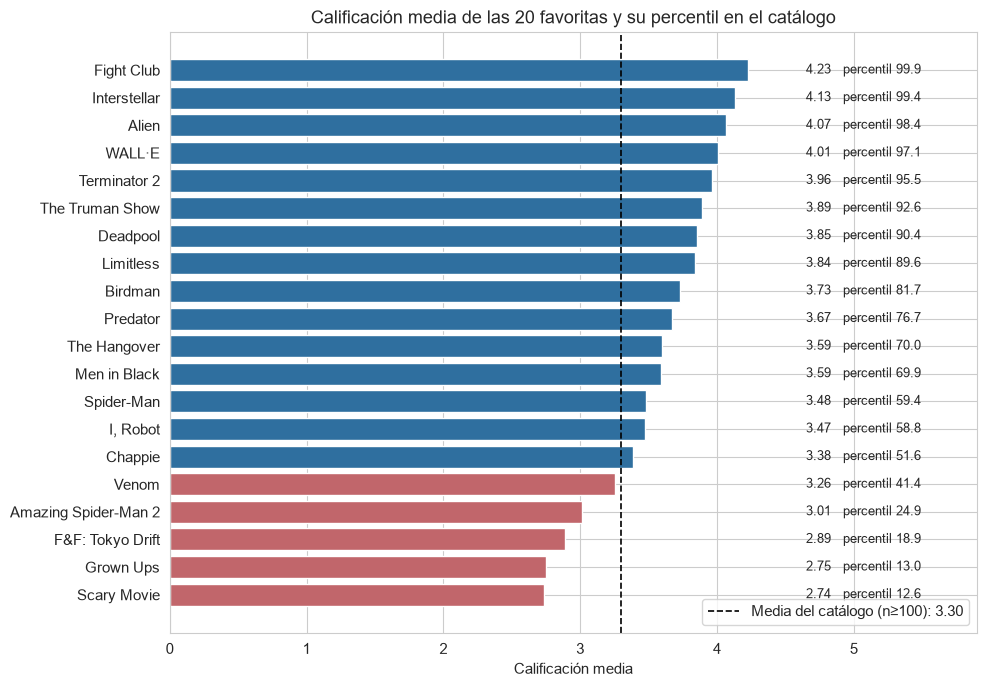

In [12]:
orden = favoritas.sort_values('avg_rating')
media_ref = base_calidad['avg_rating'].mean()

fig, ax = plt.subplots(figsize=(10, 7))
colores = np.where(orden['avg_rating'] >= media_ref, '#2f6f9f', '#c1666b')
ax.barh(orden['etiqueta'], orden['avg_rating'], color=colores)
ax.axvline(media_ref, color='black', linestyle='--', linewidth=1.2,
           label=f'Media del catálogo (n≥{UMBRAL}): {media_ref:.2f}')

for etiqueta, valor, pct in zip(orden['etiqueta'], orden['avg_rating'], orden['pct_calidad']):
    ax.text(4.65, etiqueta, f'{valor:.2f}   percentil {pct:.1f}', va='center', fontsize=9)

ax.set_xlim(0, 5.9)
ax.set_xlabel('Calificación media')
ax.set_title('Calificación media de las 20 favoritas y su percentil en el catálogo')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Resultados:** 15 de las 20 superan la media del catálogo comparable (3.30). El grupo alto lo
encabezan `Fight Club` (4.23, percentil 99.9), `Interstellar` (4.13, p99.4), `Alien` (4.07, p98.4),
`WALL·E` (4.01, p97.1) y `Terminator 2` (3.96, p95.5). En el extremo opuesto, `Scary Movie` (2.74,
p12.7), `Grown Ups` (2.75, p13.0) y `F&F: Tokyo Drift` (2.89, p19.0) quedan en el quintil inferior.

**Interpretación:** el top 20 no es homogéneo. Convive un bloque de películas de consenso alto —que
la comunidad de MovieLens también valora entre las mejores— con un bloque de comedias y acción ligera
que el resto de usuarios califica claramente por debajo de la media. Es un dato observado sobre el
gusto agregado de MovieLens, no un juicio sobre la calidad de las películas: una media baja indica
desacuerdo con el gusto mayoritario del dataset, nada más.

### 7.2 ¿Qué tan populares son dentro del dataset?

**Qué se calcula:** el número de calificaciones de cada favorita y su percentil de popularidad frente
a todas las películas calificadas.

**Por qué es relevante:** la popularidad determina cuánta evidencia respalda cada media. Una película
con 2,600 calificaciones tiene una media mucho más incierta que una con 77,000, y ese contraste
condiciona la lectura de la sección anterior.

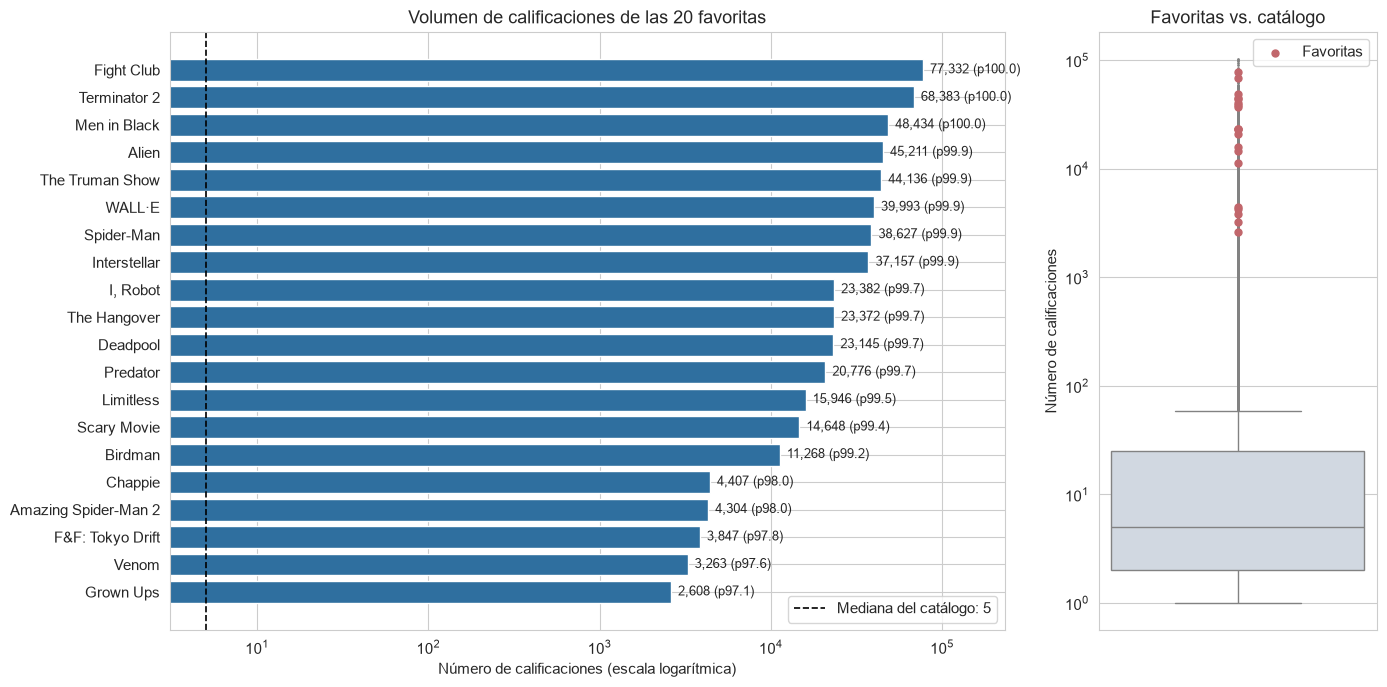

In [13]:
orden_pop = favoritas.sort_values('n_ratings')
mediana_cat = movie_stats['n_ratings'].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 7), gridspec_kw={'width_ratios': [3, 1]})

axes[0].barh(orden_pop['etiqueta'], orden_pop['n_ratings'], color='#2f6f9f')
axes[0].set_xscale('log')
axes[0].axvline(mediana_cat, color='black', linestyle='--', linewidth=1.2,
                label=f'Mediana del catálogo: {mediana_cat:.0f}')
for etiqueta, valor, pct in zip(orden_pop['etiqueta'], orden_pop['n_ratings'],
                                orden_pop['pct_popularidad']):
    axes[0].text(valor * 1.1, etiqueta, f'{valor:,.0f} (p{pct:.1f})', va='center', fontsize=9)
axes[0].set_xlim(right=favoritas['n_ratings'].max() * 3)
axes[0].set_xlabel('Número de calificaciones (escala logarítmica)')
axes[0].set_title('Volumen de calificaciones de las 20 favoritas')
axes[0].legend(loc='lower right')

sns.boxplot(y=movie_stats['n_ratings'], ax=axes[1], color='#cfd8e3', fliersize=1)
axes[1].scatter([0] * 20, favoritas['n_ratings'], color='#c1666b', zorder=3, s=25, label='Favoritas')
axes[1].set_yscale('log')
axes[1].set_ylabel('Número de calificaciones')
axes[1].set_title('Favoritas vs. catálogo')
axes[1].legend()

plt.tight_layout()
plt.show()

**Resultados:** las 20 favoritas están **todas** por encima del percentil 97 de popularidad; 13 de
ellas superan el percentil 99.5. La mediana del catálogo es de 5 calificaciones, frente a las 2,608
de la menos calificada de nuestra lista.

**Interpretación:** el top 20 del grupo está formado íntegramente por películas *mainstream*. Es
esperable —son estrenos comerciales de amplia difusión— pero tiene una consecuencia metodológica
importante: todas las medias de §7.1 se apoyan en miles de calificaciones, así que las diferencias
observadas allí no son ruido de muestra pequeña. También implica que este top 20 no es representativo
del catálogo: la comparación válida es contra películas igualmente populares, no contra las 83,852
calificadas.

### 7.3 Posición conjunta: calidad × popularidad

**Qué se calcula:** la ubicación de cada favorita en el plano popularidad (log) × calificación media,
sobre la densidad de todo el catálogo con `n≥100`.

**Por qué es relevante:** `movies_ratings.ipynb` ya mostró que ambas variables se relacionan a nivel
global; aquí interesa el **posicionamiento relativo** de nuestras películas dentro de esa nube y
detectar cuáles se apartan del patrón general.

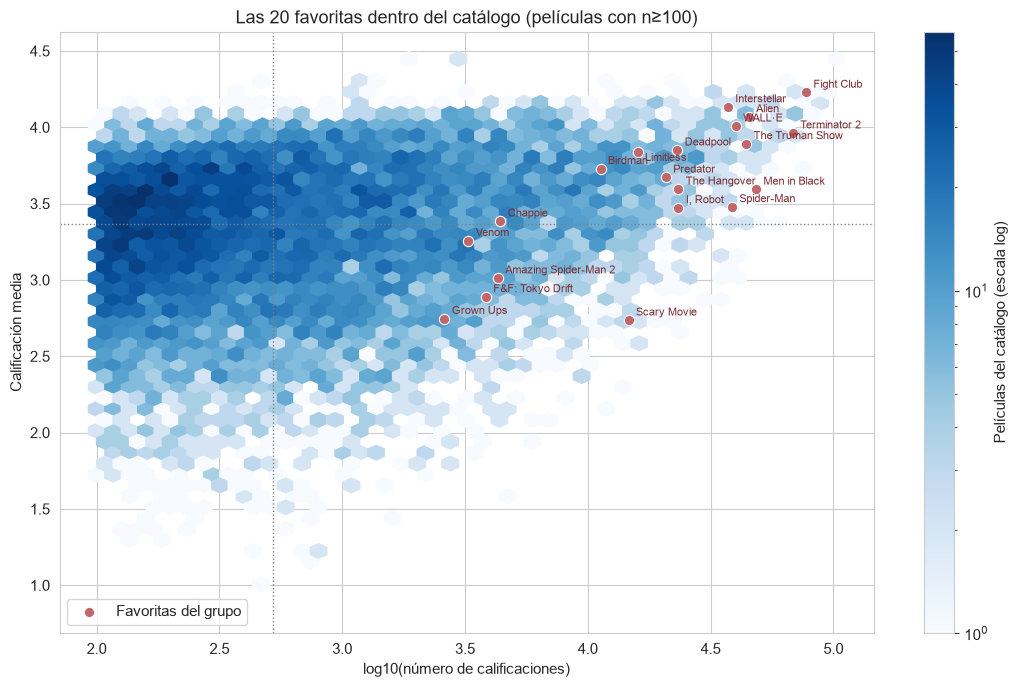

In [14]:
fig, ax = plt.subplots(figsize=(11, 7))

hb = ax.hexbin(np.log10(base_calidad['n_ratings']), base_calidad['avg_rating'],
               gridsize=45, cmap='Blues', bins='log', mincnt=1)
fig.colorbar(hb, ax=ax, label='Películas del catálogo (escala log)')

ax.scatter(np.log10(favoritas['n_ratings']), favoritas['avg_rating'],
           color='#c1666b', s=55, zorder=3, edgecolor='white', linewidth=0.8,
           label='Favoritas del grupo')
# Colocación de etiquetas: se prueban varias posiciones alrededor de cada punto y se elige la
# primera que no se solape con una etiqueta ya colocada (evita el amontonamiento en la zona densa).
CANDIDATAS = [(0.03, 0.03, 'left'), (0.03, -0.06, 'left'), (-0.03, 0.03, 'right'),
              (-0.03, -0.06, 'right'), (0.03, 0.10, 'left'), (-0.03, 0.10, 'right'),
              (0.03, -0.13, 'left'), (-0.03, -0.13, 'right')]
ANCHO_CARACTER, ALTO_ETIQUETA = 0.021, 0.055
colocadas = []

for _, fila in favoritas.sort_values('n_ratings', ascending=False).iterrows():
    x, y = np.log10(fila['n_ratings']), fila['avg_rating']
    texto = fila['etiqueta']
    ancho = len(texto) * ANCHO_CARACTER

    for dx, dy, alineacion in CANDIDATAS:
        x0 = x + dx if alineacion == 'left' else x + dx - ancho
        caja = (x0, x0 + ancho, y + dy, y + dy + ALTO_ETIQUETA)
        if not any(caja[0] < c[1] and c[0] < caja[1] and caja[2] < c[3] and c[2] < caja[3]
                   for c in colocadas):
            break

    colocadas.append(caja)
    ax.annotate(texto, (x, y), xytext=(x + dx, y + dy), ha=alineacion, fontsize=8,
                color='#7a2f33')

ax.axhline(base_calidad['avg_rating'].median(), color='gray', linestyle=':', linewidth=1)
ax.axvline(np.log10(base_calidad['n_ratings'].median()), color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('log10(número de calificaciones)')
ax.set_ylabel('Calificación media')
ax.set_title(f'Las 20 favoritas dentro del catálogo (películas con n≥{UMBRAL})')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

**Resultados:** las 20 favoritas se agrupan en el margen derecho del gráfico (alta popularidad), pero
dispersas verticalmente entre 2.7 y 4.2. Ninguna cae en el cuadrante de baja popularidad. Las más
alejadas del cuerpo de la nube son `Fight Club` (muy popular y muy bien valorada) y `Scary Movie`
(muy popular pero por debajo de casi todo lo comparable).

**Interpretación:** dentro del rango de películas masivas, la asociación entre volumen y calificación
es débil: nuestras películas comparten nivel de exposición y aun así difieren en casi 1.5 puntos de
media. La popularidad de una película no permite anticipar cómo será valorada, y en este subconjunto
la dispersión vertical lo hace evidente.

### 7.4 ¿Consenso o polarización?

**Qué se calcula:** la distribución interna de calificaciones de cada favorita —proporción de cada
valor de 0.5 a 5.0—, su desviación estándar y el porcentaje de notas altas (≥4.5) y bajas (≤2.0).

**Por qué es relevante:** dos películas pueden llegar a la misma media por caminos opuestos:
consenso tibio, o mezcla de entusiastas y detractores. La media sola oculta esa diferencia.

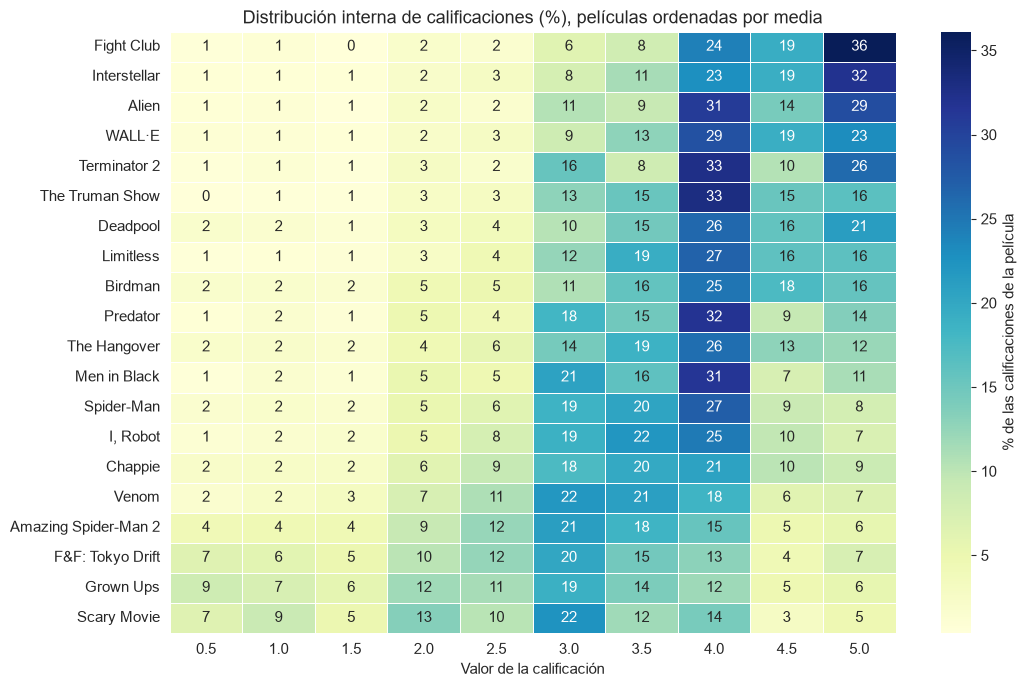

In [15]:
dist = (
    fav_ratings.groupby(['movieId', 'rating']).size()
    .unstack(fill_value=0)
    .pipe(lambda d: d.div(d.sum(axis=1), axis=0) * 100)
)
dist.index = favoritas.loc[dist.index, 'etiqueta']
dist = dist.loc[favoritas.sort_values('avg_rating', ascending=False)['etiqueta']]

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(dist, cmap='YlGnBu', annot=True, fmt='.0f', linewidths=0.4,
            cbar_kws={'label': '% de las calificaciones de la película'}, ax=ax)
ax.set_xlabel('Valor de la calificación')
ax.set_ylabel('')
ax.set_title('Distribución interna de calificaciones (%), películas ordenadas por media')
plt.tight_layout()
plt.show()

In [16]:
polarizacion = pd.DataFrame({
    'media': favoritas['avg_rating'],
    'std': favoritas['std_rating'],
    'pct_>=4.5': fav_ratings[fav_ratings['rating'] >= 4.5].groupby('movieId').size() / favoritas['n_ratings'] * 100,
    'pct_<=2.0': fav_ratings[fav_ratings['rating'] <= 2.0].groupby('movieId').size() / favoritas['n_ratings'] * 100,
})
polarizacion.index = favoritas.loc[polarizacion.index, 'etiqueta']   # alineado por movieId

std_catalogo = ratings.groupby('movieId')['rating'].std().reindex(base_calidad.index)
print(f"Desviación estándar media de las películas con n>={UMBRAL}: {std_catalogo.mean():.3f}")
polarizacion.sort_values('std', ascending=False).round(2)

Desviación estándar media de las películas con n>=100: 0.977


,media,std,pct_>=4.5,pct_<=2.0
etiqueta,,,,
Grown Ups,2.75,1.24,10.28,33.63
F&F: Tokyo Drift,2.89,1.21,11.83,27.97
Scary Movie,2.74,1.18,7.54,33.83
Amazing Spider-Man 2,3.01,1.09,10.27,22.42
Chappie,3.38,1.04,19.02,13.41
Birdman,3.73,1.03,33.19,9.89
The Hangover,3.59,1.02,25.11,10.40
Deadpool,3.85,1.01,37.00,7.87
Venom,3.26,0.98,13.18,14.53


**Resultados:** la desviación estándar de las favoritas va de 0.82 (`The Truman Show`) a 1.24
(`Grown Ups`), frente a una media de 0.98 en el catálogo comparable. Casos extremos: `Grown Ups`
recibe un 33.6% de notas ≤2.0 y solo un 10.3% de notas ≥4.5, y `Scary Movie` repite el patrón (33.8%
frente a 7.5%). En el otro extremo, `Fight Club` acumula 55.5% de notas ≥4.5 con apenas 3.9% de notas
≤2.0, e `Interstellar` 51.1% frente a 4.2%.

**Interpretación:** las favoritas peor valoradas no son películas "medianamente aceptadas", sino
películas **rechazadas por un tercio de quienes las califican**: su baja media proviene de una
concentración real en el extremo inferior de la escala, no de una mayoría de notas intermedias. Las
mejor valoradas combinan media alta y dispersión baja, señal de consenso amplio. `Birdman` y
`Deadpool` ocupan una posición intermedia —media alta con dispersión superior a la del catálogo—, es
decir, dividen más opiniones que el resto del grupo alto.

### 7.5 Perfil de géneros del grupo

**Qué se calcula:** la prevalencia de cada género entre nuestras 20 películas frente a su prevalencia
en el catálogo completo.

**Por qué es relevante:** identifica el sesgo temático del gusto del grupo. Se usan las columnas
binarias de `utils_.get_genre_columns()`, que no son excluyentes: una película cuenta en todos sus
géneros.

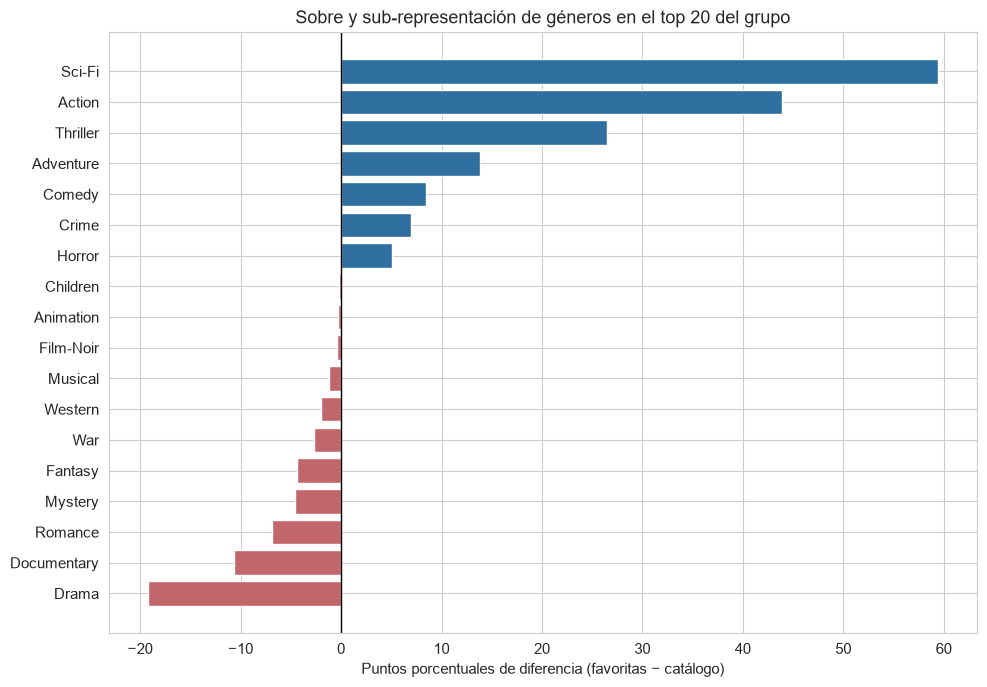

,favoritas,catalogo,diferencia
Sci-Fi,65.0,5.6,59.4
Action,55.0,11.1,43.9
Thriller,40.0,13.5,26.5
Adventure,20.0,6.2,13.8
Comedy,35.0,26.5,8.5
Crime,15.0,8.0,7.0
Horror,15.0,9.9,5.1
Children,5.0,5.2,-0.2
Animation,5.0,5.3,-0.3
Film-Noir,0.0,0.4,-0.4


In [17]:
gen_fav = movies_gen[movies_gen['movieId'].isin(FAV_IDS)][GENEROS].mean() * 100
gen_cat = movies_gen[GENEROS].mean() * 100

comp_gen = pd.DataFrame({'favoritas': gen_fav, 'catalogo': gen_cat})
comp_gen['diferencia'] = comp_gen['favoritas'] - comp_gen['catalogo']
comp_gen = comp_gen.sort_values('diferencia')

fig, ax = plt.subplots(figsize=(10, 7))
colores = np.where(comp_gen['diferencia'] >= 0, '#2f6f9f', '#c1666b')
ax.barh(comp_gen.index, comp_gen['diferencia'], color=colores)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Puntos porcentuales de diferencia (favoritas − catálogo)')
ax.set_title('Sobre y sub-representación de géneros en el top 20 del grupo')
plt.tight_layout()
plt.show()

comp_gen.sort_values('diferencia', ascending=False).round(1)

**Resultados:** `Sci-Fi` aparece en el 65% de nuestras películas frente al 5.6% del catálogo (+59.4
puntos porcentuales), `Action` en el 55% frente al 11.1% (+43.9) y `Thriller` en el 40% frente al
13.5% (+26.5). Del lado opuesto, `Drama` está fuertemente sub-representado y géneros como
`Documentary`, `Romance`, `War` o `Western` no aparecen en absoluto.

**Interpretación:** el gusto del grupo es marcadamente de **ciencia ficción y acción
contemporánea**, muy alejado del perfil del catálogo, donde domina el drama. La comparación describe
el conjunto elegido; con 20 películas no cabe inferir nada sobre la población de usuarios ni sobre la
industria.

### 7.6 ¿Son buenas *dentro de su propio género*?

**Qué se calcula:** la diferencia entre la calificación media de cada favorita y la media de las
películas de su(s) mismo(s) género(s) en el catálogo comparable (`n≥100`).

**Por qué es relevante:** en §7.1 la referencia era el catálogo entero, pero los géneros no se
califican igual (el drama recibe medias más altas que la comedia). Comparar cada película contra su
propio género es una referencia más justa.

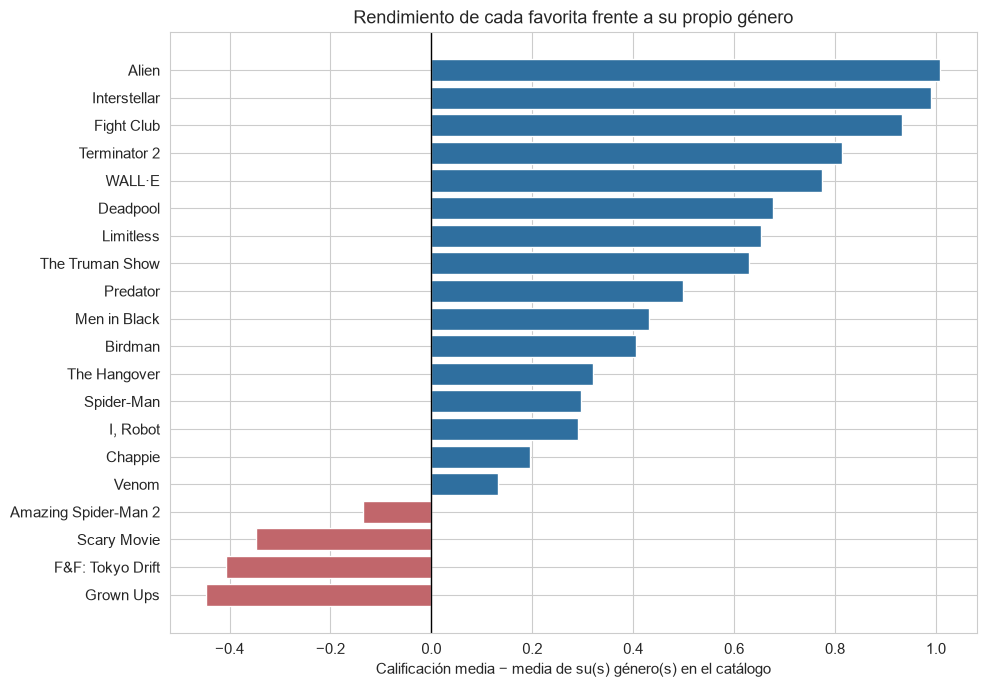

Media por género en el catálogo comparable:
Film-Noir      3.707
Documentary    3.648
War            3.538
Drama          3.452
Western        3.397
Animation      3.372
Romance        3.359
Crime          3.355
Musical        3.354
Mystery        3.351
Thriller       3.228
Fantasy        3.218
Adventure      3.209
Comedy         3.193
Action         3.152
Sci-Fi         3.142
Children       3.081
Horror         2.977


,etiqueta,generos,avg_rating,media_genero,diferencia
movieId,,,,,
79134,Grown Ups,Comedy,2.747,3.193,-0.446
46335,F&F: Tokyo Drift,Action|Crime|Drama|Thriller,2.890,3.297,-0.407
3785,Scary Movie,Comedy|Horror,2.736,3.085,-0.348
110553,Amazing Spider-Man 2,Action|Sci-Fi|IMAX,3.013,3.147,-0.135
192389,Venom,Action|Horror|Sci-Fi|Thriller,3.258,3.125,0.133
120466,Chappie,Action|Thriller,3.385,3.190,0.195
8644,"I, Robot",Action|Adventure|Sci-Fi|Thriller,3.473,3.183,0.290
5349,Spider-Man,Action|Adventure|Sci-Fi|Thriller,3.479,3.183,0.297
69122,The Hangover,Comedy|Crime,3.595,3.274,0.321


In [18]:
base_gen = movies_gen.set_index('movieId').join(movie_stats, how='inner')
base_gen = base_gen[base_gen['n_ratings'] >= UMBRAL]
media_por_genero = pd.Series({g: base_gen.loc[base_gen[g] == 1, 'avg_rating'].mean() for g in GENEROS})

gen_bin = movies_gen.set_index('movieId').loc[FAV_IDS, GENEROS]
referencia = gen_bin.apply(lambda fila: media_por_genero[fila[fila == 1].index].mean(), axis=1)

comparacion = pd.DataFrame({
    'etiqueta': favoritas['etiqueta'],
    'generos': favoritas['genres'],
    'avg_rating': favoritas['avg_rating'],
    'media_genero': referencia,
})
comparacion['diferencia'] = comparacion['avg_rating'] - comparacion['media_genero']
comparacion = comparacion.sort_values('diferencia')

fig, ax = plt.subplots(figsize=(10, 7))
colores = np.where(comparacion['diferencia'] >= 0, '#2f6f9f', '#c1666b')
ax.barh(comparacion['etiqueta'], comparacion['diferencia'], color=colores)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Calificación media − media de su(s) género(s) en el catálogo')
ax.set_title('Rendimiento de cada favorita frente a su propio género')
plt.tight_layout()
plt.show()

print("Media por género en el catálogo comparable:")
print(media_por_genero.sort_values(ascending=False).round(3).to_string())
comparacion.round(3)

**Resultados:** 17 de las 20 superan la media de su género. Las mayores ventajas son `Alien` (+1.01
sobre `Horror|Sci-Fi`), `Interstellar` (+0.99) y `Fight Club` (+0.93). Las tres por debajo son
`Grown Ups` (−0.45 sobre `Comedy`), `F&F: Tokyo Drift` (−0.41) y `Scary Movie` (−0.35).

**Interpretación:** cambiar la referencia matiza el resultado de §7.1. Películas que allí quedaban en
la zona media del catálogo, como `Spider-Man` (p59) o `I, Robot` (p59), están en realidad ~0.29
puntos por encima de la media de acción y ciencia ficción: su percentil moderado se explica en parte
porque compiten en géneros que el conjunto de usuarios de MovieLens califica más bajo. En cambio
`Grown Ups` y `Scary Movie` siguen por debajo incluso frente a su propio género, de modo que su
posición no es un efecto de composición.

### 7.7 Distribución temporal: años de estreno

**Qué se calcula:** el año de estreno de las 20 favoritas sobre la distribución del catálogo por
década.

**Por qué es relevante:** sitúa el gusto del grupo en el tiempo y advierte de un sesgo que afecta a
los análisis siguientes: el dataset termina en octubre de 2023, así que los estrenos recientes
acumulan menos años de exposición.

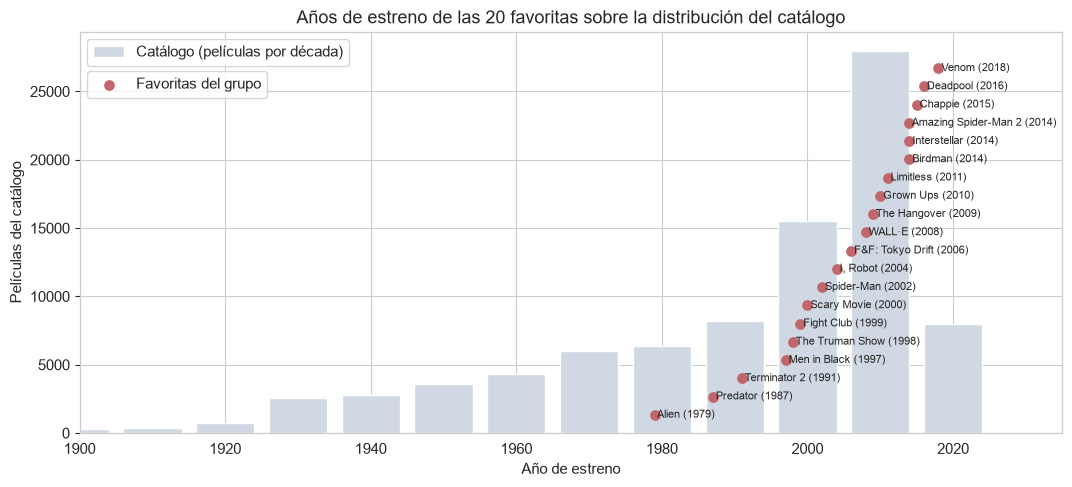

count      20.0
mean     2004.6
std        10.5
min      1979.0
25%      1998.8
50%      2007.0
75%      2014.0
max      2018.0


In [19]:
por_decada = ((movies['anio'] // 10) * 10).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(por_decada.index, por_decada.values, width=8, color='#cfd8e3',
       label='Catálogo (películas por década)')
ax.set_xlabel('Año de estreno')
ax.set_ylabel('Películas del catálogo')
ax.set_xlim(1900, 2035)

orden_anio = favoritas.sort_values('anio')
ax2 = ax.twinx()
ax2.scatter(orden_anio['anio'], range(20), color='#c1666b', s=45, zorder=3,
            label='Favoritas del grupo')
for y, (_, fila) in enumerate(orden_anio.iterrows()):
    ax2.annotate(f" {fila['etiqueta']} ({fila['anio']})", (fila['anio'], y),
                 fontsize=8, va='center', ha='left')
ax2.set_ylim(-1, 21)
ax2.set_yticks([])

ax.legend(loc='upper left')
ax2.legend(loc='upper left', bbox_to_anchor=(0, 0.92))
ax.set_title('Años de estreno de las 20 favoritas sobre la distribución del catálogo')
plt.tight_layout()
plt.show()

print(favoritas['anio'].describe().round(1).to_string())

**Resultados:** las favoritas se estrenaron entre 1979 y 2018, con mediana en 2007 y 13 de 20
posteriores al año 2000. El catálogo, en cambio, concentra su masa en las décadas de 2000 y 2010 por
el crecimiento del número de títulos registrados.

**Interpretación:** el gusto del grupo se concentra en el cine de las dos últimas décadas, con unas
pocas referencias clásicas de acción y ciencia ficción de los ochenta y noventa (`Alien`, `Predator`,
`Terminator 2`). La distribución del catálogo por década ya fue analizada en `movies.ipynb`; aquí
solo se usa como fondo de comparación.

### 7.8 ¿Envejecen bien? Evolución de la calificación en el tiempo

**Qué se calcula:** para cada favorita estrenada dentro de la ventana de datos (1996 en adelante), la
diferencia entre la calificación media recibida en sus **primeros dos años** y la recibida después.

**Por qué es relevante:** `rating_datetime` permite separar la recepción inicial de la valoración
posterior; es la única forma, con estos datos, de aproximar si la percepción de una película cambió
con el tiempo.

**Limitación del método:** las estrenadas antes de 1996 se excluyen porque el dataset no cubre su
lanzamiento, y `release_year` solo tiene granularidad anual (`YYYY-01-01`), así que la ventana de dos
años es aproximada.

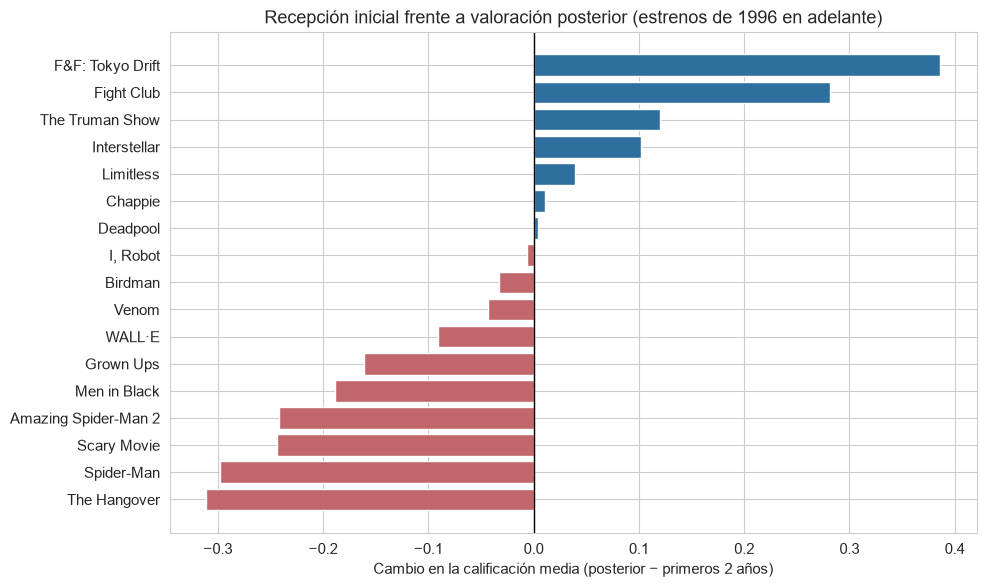

,media_2_primeros_anios,n_2_primeros_anios,media_posterior,cambio
etiqueta,,,,
The Hangover,3.864,3147,3.553,-0.311
Spider-Man,3.744,4304,3.446,-0.298
Scary Movie,2.946,2050,2.702,-0.244
Amazing Spider-Man 2,3.203,907,2.962,-0.242
Men in Black,3.775,1802,3.587,-0.189
Grown Ups,2.890,295,2.729,-0.161
WALL·E,4.089,4283,3.998,-0.091
Venom,3.285,1215,3.241,-0.043
Birdman,3.754,2456,3.721,-0.033


In [20]:
fav_tmp = fav_ratings.merge(favoritas[['anio', 'etiqueta']], left_on='movieId', right_index=True)
fav_tmp['dias_desde_estreno'] = (
    fav_tmp['rating_datetime'] - pd.to_datetime(fav_tmp['anio'].astype(str) + '-01-01')
).dt.days

en_ventana = fav_tmp[fav_tmp['anio'] >= 1996]
inicial = (en_ventana[en_ventana['dias_desde_estreno'] <= 730]
           .groupby('etiqueta')['rating'].agg(['mean', 'size']))
posterior = en_ventana[en_ventana['dias_desde_estreno'] > 730].groupby('etiqueta')['rating'].mean()

envejecimiento = pd.DataFrame({
    'media_2_primeros_anios': inicial['mean'],
    'n_2_primeros_anios': inicial['size'],
    'media_posterior': posterior,
})
envejecimiento['cambio'] = envejecimiento['media_posterior'] - envejecimiento['media_2_primeros_anios']
envejecimiento = envejecimiento.sort_values('cambio')

fig, ax = plt.subplots(figsize=(10, 6))
colores = np.where(envejecimiento['cambio'] >= 0, '#2f6f9f', '#c1666b')
ax.barh(envejecimiento.index, envejecimiento['cambio'], color=colores)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Cambio en la calificación media (posterior − primeros 2 años)')
ax.set_title('Recepción inicial frente a valoración posterior (estrenos de 1996 en adelante)')
plt.tight_layout()
plt.show()

envejecimiento.round(3)

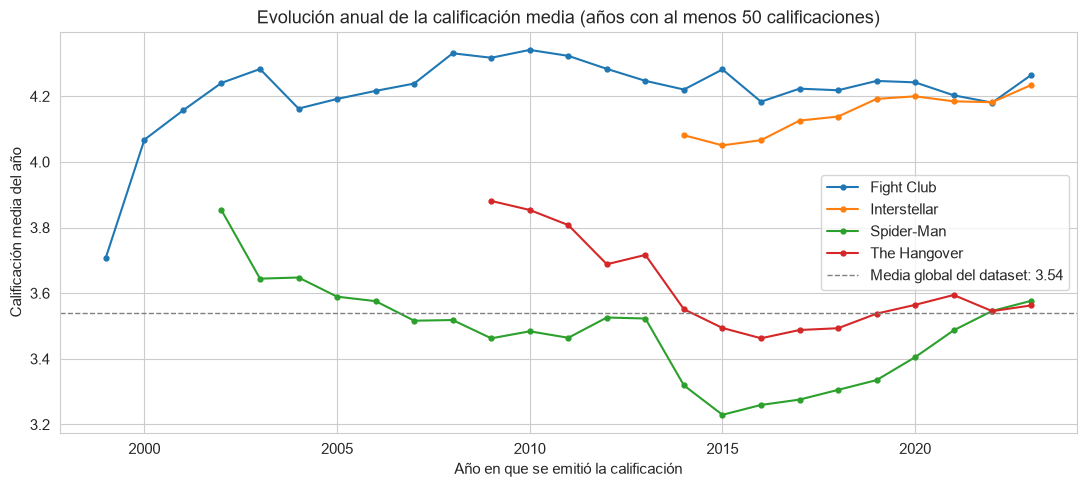

In [21]:
seleccion = ['Fight Club', 'The Hangover', 'Interstellar', 'Spider-Man']
serie = (fav_tmp[fav_tmp['etiqueta'].isin(seleccion)]
         .assign(anio_rating=lambda d: d['rating_datetime'].dt.year)
         .groupby(['etiqueta', 'anio_rating'])['rating']
         .agg(['mean', 'size'])
         .reset_index())
serie = serie[serie['size'] >= 50]

fig, ax = plt.subplots(figsize=(11, 5))
for etiqueta, grupo in serie.groupby('etiqueta'):
    ax.plot(grupo['anio_rating'], grupo['mean'], marker='o', markersize=3.5, label=etiqueta)

media_global = ratings['rating'].mean()
ax.axhline(media_global, color='gray', linestyle='--', linewidth=1,
           label=f'Media global del dataset: {media_global:.2f}')
ax.set_xlabel('Año en que se emitió la calificación')
ax.set_ylabel('Calificación media del año')
ax.set_title('Evolución anual de la calificación media (años con al menos 50 calificaciones)')
ax.legend()
plt.tight_layout()
plt.show()

**Resultados:** el cambio va de −0.31 (`The Hangover`) a +0.39 (`F&F: Tokyo Drift`). Suben
`F&F: Tokyo Drift` (+0.39), `Fight Club` (+0.28), `The Truman Show` (+0.12) e `Interstellar` (+0.10);
bajan `The Hangover` (−0.31), `Spider-Man` (−0.30), `Scary Movie` (−0.24) y `Amazing Spider-Man 2`
(−0.24). En la serie anual, `Fight Club` pasa de ~3.96 en sus dos primeros años a estabilizarse por
encima de 4.2 en la última década, mientras `The Hangover` y `Spider-Man` caen por debajo de la media
global del dataset en los años posteriores a su estreno (`Spider-Man` se recupera parcialmente a
partir de 2016, sin volver a su nivel inicial).

**Interpretación:** se observan dos comportamientos asociados al tipo de película: las comedias y los
*blockbusters* de estreno pierden valoración con el tiempo, y las películas con componente de culto o
de ciencia ficción la ganan. Ahora bien, esto **no puede atribuirse a un cambio de opinión de los
mismos usuarios**: cada calificación proviene de una persona distinta, y quien califica una película
años después de su estreno es un público auto-seleccionado que la buscó porque ya le interesaba. Lo
que se observa es un cambio en la composición de quienes califican; los datos disponibles no permiten
distinguir esa explicación de un cambio real de percepción.

### 7.9 Audiencia compartida entre las favoritas

**Qué se calcula:** cuántos usuarios del dataset calificaron nuestras películas, la **similitud de
Jaccard** entre cada par de favoritas (usuarios en común sobre usuarios que calificaron al menos una
de las dos) y la correlación de sus calificaciones entre quienes vieron ambas.

**Por qué es relevante:** `userId` conecta `ratings` y `tags` y habilita un análisis que los
notebooks de `main/` no abordan: si nuestras 20 películas las ve el mismo público o públicos
distintos. Jaccard mide coincidencia de audiencia; la correlación mide coincidencia de gusto.

In [22]:
favs_por_usuario = fav_ratings.groupby('userId')['movieId'].nunique()
n_usuarios = ratings['userId'].nunique()

print(f"Usuarios en el dataset: {n_usuarios:,}")
for k in (1, 5, 10, 15, 20):
    n = (favs_por_usuario >= k).sum()
    print(f"  calificaron al menos {k:>2} de nuestras 20: {n:>7,} ({n / n_usuarios * 100:5.1f}% de los usuarios)")
print(f"\nPromedio de favoritas calificadas por quienes calificaron al menos una: {favs_por_usuario.mean():.2f}")

Usuarios en el dataset: 200,948
  calificaron al menos  1 de nuestras 20: 148,982 ( 74.1% de los usuarios)
  calificaron al menos  5 de nuestras 20:  43,023 ( 21.4% de los usuarios)
  calificaron al menos 10 de nuestras 20:   9,586 (  4.8% de los usuarios)
  calificaron al menos 15 de nuestras 20:   1,765 (  0.9% de los usuarios)
  calificaron al menos 20 de nuestras 20:      51 (  0.0% de los usuarios)

Promedio de favoritas calificadas por quienes calificaron al menos una: 3.69


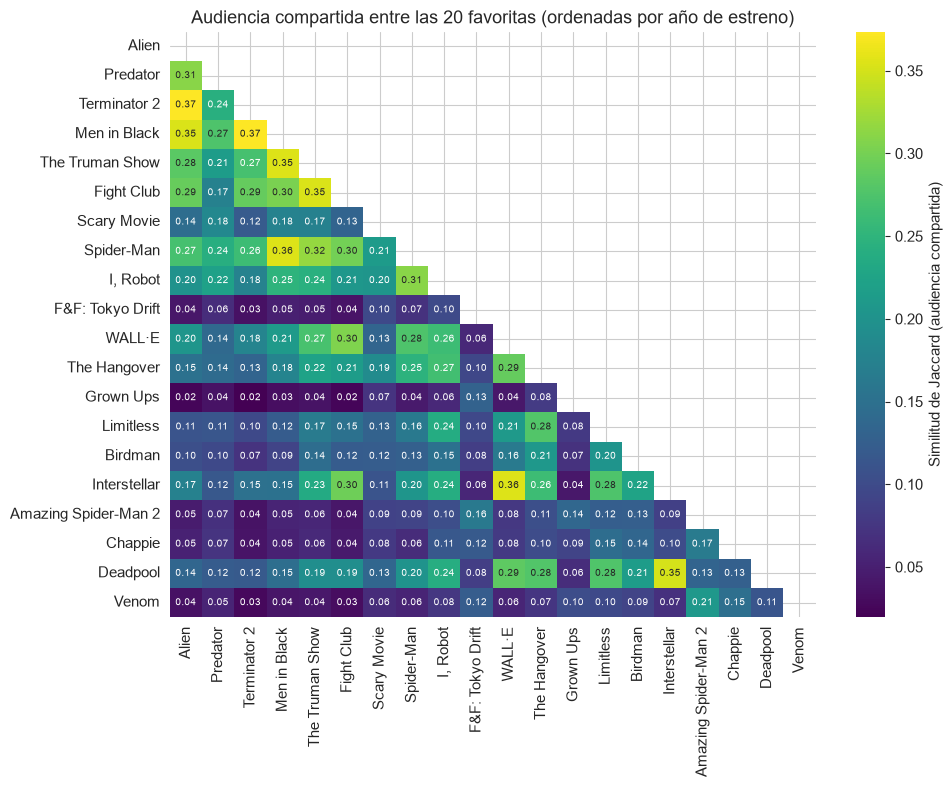

In [23]:
conjuntos = {m: set(g) for m, g in fav_ratings.groupby('movieId')['userId']}
orden_j = favoritas.sort_values('anio').index

jaccard = pd.DataFrame(np.eye(20), index=orden_j, columns=orden_j)
for a, b in itertools.combinations(orden_j, 2):
    interseccion = len(conjuntos[a] & conjuntos[b])
    union = len(conjuntos[a]) + len(conjuntos[b]) - interseccion
    jaccard.loc[a, b] = jaccard.loc[b, a] = interseccion / union

jaccard.index = jaccard.columns = favoritas.loc[orden_j, 'etiqueta']

fig, ax = plt.subplots(figsize=(10, 8))
mascara = np.triu(np.ones_like(jaccard, dtype=bool))
sns.heatmap(jaccard, mask=mascara, cmap='viridis', annot=True, fmt='.2f', annot_kws={'size': 7},
            cbar_kws={'label': 'Similitud de Jaccard (audiencia compartida)'}, ax=ax)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Audiencia compartida entre las 20 favoritas (ordenadas por año de estreno)')
plt.tight_layout()
plt.show()

In [24]:
# Correlación de gusto: solo sobre los usuarios que calificaron ambas películas
notas = {m: g.set_index('userId')['rating'] for m, g in fav_ratings.groupby('movieId')}

pares = []
for a, b in itertools.combinations(orden_j, 2):
    comunes = conjuntos[a] & conjuntos[b]
    if len(comunes) < 500:
        continue
    indice = list(comunes)
    pares.append((favoritas.loc[a, 'etiqueta'], favoritas.loc[b, 'etiqueta'], len(comunes),
                  notas[a].loc[indice].corr(notas[b].loc[indice])))

correlaciones = pd.DataFrame(pares, columns=['pelicula_a', 'pelicula_b', 'usuarios_comunes', 'correlacion'])
print("Pares con mayor correlación de calificaciones:")
print(correlaciones.sort_values('correlacion', ascending=False).head(8).round(3).to_string(index=False))
print("\nPares con menor correlación:")
print(correlaciones.sort_values('correlacion').head(5).round(3).to_string(index=False))

Pares con mayor correlación de calificaciones:
          pelicula_a           pelicula_b  usuarios_comunes  correlacion
Amazing Spider-Man 2                Venom              1308        0.532
    F&F: Tokyo Drift Amazing Spider-Man 2              1140        0.501
    F&F: Tokyo Drift            Grown Ups               739        0.500
           Grown Ups                Venom               540        0.490
           Grown Ups Amazing Spider-Man 2               828        0.485
            I, Robot            Limitless              7543        0.474
Amazing Spider-Man 2              Chappie              1241        0.472
        Men in Black             I, Robot             14279        0.468

Pares con menor correlación:
      pelicula_a           pelicula_b  usuarios_comunes  correlacion
           Alien            Grown Ups              1150       -0.052
       Grown Ups              Birdman               906       -0.008
         Birdman Amazing Spider-Man 2              1742    

**Resultados:** 148,982 usuarios (74.1% del dataset) calificaron al menos una de nuestras 20
películas, 43,023 calificaron cinco o más y solo 51 calificaron las veinte; quien califica alguna
califica 3.7 en promedio. Los valores de Jaccard más altos (0.35–0.37) se dan entre los clásicos de
acción y ciencia ficción de los ochenta y noventa —`Alien`, `Predator`, `Terminator 2`,
`Men in Black`— y entre `WALL·E` e `Interstellar` (0.36); los más bajos (0.02–0.07) corresponden a
`Grown Ups`, `F&F: Tokyo Drift`, `Venom` y `Chappie`, todas ellas entre las favoritas con menos
evaluadores.

**Interpretación:** el alcance del top 20 es enorme —tres de cada cuatro usuarios del dataset
calificaron alguna—, pero la superposición está fuertemente condicionada por la **época** y el
**volumen**: dos películas antiguas y muy calificadas comparten más audiencia simplemente porque
llevan más años acumulando calificaciones. Jaccard, por construcción, penaliza a las películas con
pocos evaluadores; de ahí que la correlación sobre usuarios comunes sea la medida complementaria
adecuada, porque informa sobre el gusto y no sobre la exposición.

### 7.10 ¿Qué otras películas prefieren los usuarios afines a nuestro gusto?

**Qué se calcula:** se define un grupo de **usuarios afines** —los que calificaron con 4.0 o más al
menos 5 de nuestras 20 favoritas— y se compara, para cada película del dataset, la media que le dan
esos usuarios frente a su media global (*lift*).

**Por qué es relevante:** es la forma de responder "qué más encaja con este gusto" usando únicamente
el dataset procesado, sin recurrir a fuentes externas.

**Control necesario:** los usuarios afines podrían calificar todo más alto que la media. Ese sesgo de
generosidad se mide y se descuenta del lift.

In [25]:
MIN_FAVS, MIN_RATING, MIN_N = 5, 4.0, 1000

afines = (fav_ratings[fav_ratings['rating'] >= MIN_RATING]
          .groupby('userId')['movieId'].nunique()
          .pipe(lambda s: s[s >= MIN_FAVS].index))

ratings_afines = ratings[ratings['userId'].isin(set(afines))]
sesgo = ratings_afines['rating'].mean() - ratings['rating'].mean()

print(f"Usuarios afines (>= {MIN_FAVS} favoritas con nota >= {MIN_RATING}): {len(afines):,}")
print(f"Calificaciones emitidas por ellos: {len(ratings_afines):,}")
print(f"Media global del dataset: {ratings['rating'].mean():.3f} | "
      f"media de los afines: {ratings_afines['rating'].mean():.3f}")
print(f"Sesgo de generosidad a descontar: {sesgo:+.3f} puntos")

Usuarios afines (>= 5 favoritas con nota >= 4.0): 20,142
Calificaciones emitidas por ellos: 9,977,816
Media global del dataset: 3.540 | media de los afines: 3.598
Sesgo de generosidad a descontar: +0.058 puntos


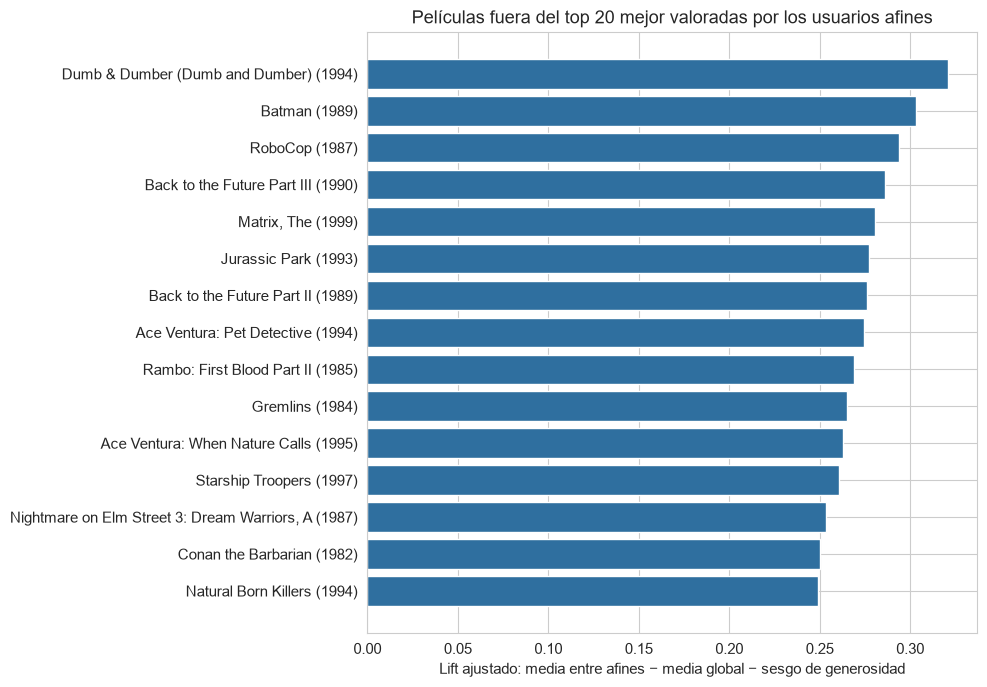

,title,anio,genres,n_afines,avg_afines,avg_rating,lift
movieId,,,,,,,
231,Dumb & Dumber (Dumb and Dumber),1994,Adventure|Comedy,7218,3.361,2.983,0.321
592,Batman,1989,Action|Crime|Thriller,7739,3.771,3.410,0.303
2985,RoboCop,1987,Action|Crime|Drama|Sci-Fi|Thriller,6518,3.744,3.393,0.294
2012,Back to the Future Part III,1990,Adventure|Comedy|Sci-Fi|Western,8136,3.711,3.368,0.286
2571,"Matrix, The",1999,Action|Sci-Fi|Thriller,18778,4.495,4.156,0.281
480,Jurassic Park,1993,Action|Adventure|Sci-Fi|Thriller,13407,4.034,3.699,0.277
2011,Back to the Future Part II,1989,Adventure|Comedy|Sci-Fi,9430,3.927,3.594,0.276
344,Ace Ventura: Pet Detective,1994,Comedy,7717,3.334,3.002,0.275
2402,Rambo: First Blood Part II,1985,Action|Adventure|Thriller,2128,3.205,2.878,0.269


In [26]:
stats_afines = ratings_afines.groupby('movieId')['rating'].agg(n_afines='count', avg_afines='mean')

lift = stats_afines.join(movie_stats)
lift = lift[lift['n_afines'] >= MIN_N]
lift['lift'] = lift['avg_afines'] - lift['avg_rating'] - sesgo      # ajustado por generosidad
lift = lift.join(movies.set_index('movieId')[['title', 'anio', 'genres']])

recomendadas = lift[~lift.index.isin(FAV_IDS)].sort_values('lift', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
etiquetas = recomendadas['title'] + ' (' + recomendadas['anio'].astype(str) + ')'
ax.barh(etiquetas[::-1], recomendadas['lift'][::-1], color='#2f6f9f')
ax.set_xlabel('Lift ajustado: media entre afines − media global − sesgo de generosidad')
ax.set_title('Películas fuera del top 20 mejor valoradas por los usuarios afines')
plt.tight_layout()
plt.show()

recomendadas[['title', 'anio', 'genres', 'n_afines', 'avg_afines', 'avg_rating', 'lift']].round(3)

**Resultados:** 20,142 usuarios cumplen el criterio de afinidad y emitieron cerca de 10 millones de
calificaciones. Su sesgo de generosidad es pequeño (+0.058 puntos), muy inferior a los *lifts*
observados (del orden de +0.25 a +0.32 ya ajustados), de modo que las diferencias no se explican por
ese sesgo. Encabezan la lista `Dumb & Dumber`, `Batman` (1989), `RoboCop`,
`Back to the Future Part III` y `Matrix, The`.

**Interpretación:** el perfil que emerge es coherente con §7.5 y §7.7: acción y ciencia ficción de
los ochenta y noventa, más comedia popular de la misma época. Es una **asociación entre
preferencias**, no una predicción individual: indica que quienes valoran alto nuestras favoritas
tienden a valorar estas películas por encima de la media general, no que vayan a gustarle a alguien
del grupo en particular. El umbral `n_afines ≥ 1000` evita que películas de nicho con pocos
evaluadores dominen el ranking por azar.

### 7.11 ¿Con qué palabras describen los usuarios nuestras favoritas?

**Qué se calcula:** las etiquetas de texto libre (`tags`) asociadas a cada favorita y el vocabulario
más frecuente del conjunto.

**Por qué es relevante:** `tags` aporta la dimensión cualitativa que `ratings` no tiene: describe
*por qué* una película resulta memorable, no solo cuánto gusta.

**Advertencia metodológica:** `tags.ipynb` documenta que un único usuario domina el volumen de
etiquetado del dataset. Por eso aquí cada etiqueta se cuenta una sola vez por usuario y película, y
el gráfico mide **usuarios distintos** que aplicaron cada término, no repeticiones.

In [27]:
tags_unicos = tags_fav.drop_duplicates(subset=['userId', 'movieId', 'tag'])

resumen_tags = pd.DataFrame({
    'etiqueta': favoritas['etiqueta'],
    'n_tags': tags_unicos.groupby('movieId').size(),
    'n_usuarios': tags_unicos.groupby('movieId')['userId'].nunique(),
    'tags_principales': tags_unicos.groupby('movieId')['tag'].agg(
        lambda s: ', '.join(s.value_counts().head(5).index)),
}).set_index('etiqueta')

resumen_tags.sort_values('n_tags', ascending=False)

,n_tags,n_usuarios,tags_principales
etiqueta,,,
Fight Club,5532,767,"twist ending, psychology, dark comedy, social commentary..."
Interstellar,5477,659,"space, thought-provoking, sci-fi, time travel, christoph..."
Alien,2158,334,"sci-fi, space, aliens, atmospheric, horror"
Terminator 2,1982,276,"arnold schwarzenegger, time travel, action, sci-fi, arti..."
Deadpool,1886,238,"dark humor, funny, 4th wall, antihero, marvel"
The Truman Show,1877,326,"social commentary, dark comedy, dystopia, jim carrey, al..."
WALL·E,1763,309,"pixar, dystopia, sci-fi, robots, social commentary"
Birdman,1116,187,"great performances, magical realism, single shot, psycho..."
"I, Robot",1099,174,"artificial intelligence, robots, sci-fi, will smith, fut..."


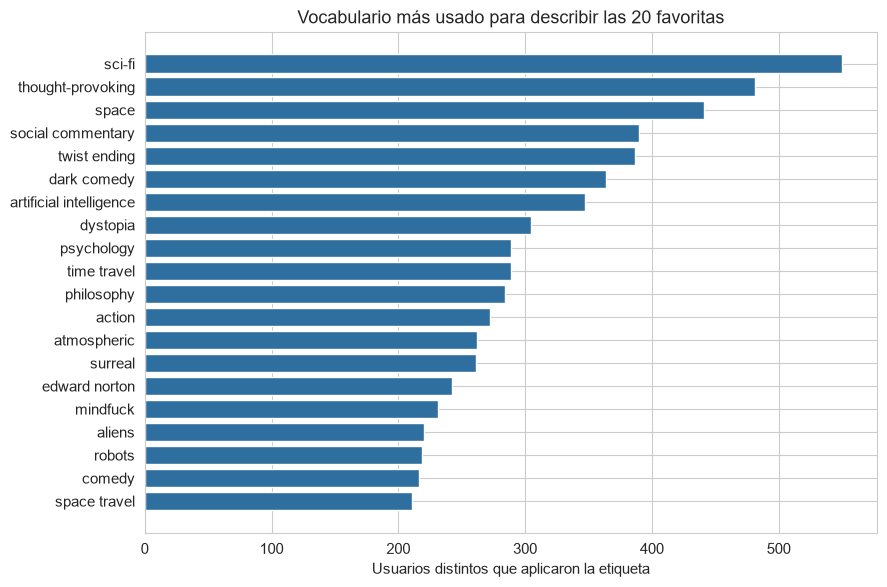

In [28]:
top_tags = (tags_unicos.groupby('tag')['userId'].nunique()
            .sort_values(ascending=False).head(20))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_tags.index[::-1], top_tags.values[::-1], color='#2f6f9f')
ax.set_xlabel('Usuarios distintos que aplicaron la etiqueta')
ax.set_title('Vocabulario más usado para describir las 20 favoritas')
plt.tight_layout()
plt.show()

**Resultados:** las 20 favoritas acumulan unas 30,000 etiquetas de 2,409 usuarios distintos.
`Fight Club` (twist ending, psychology, dark comedy) e `Interstellar` (space, thought-provoking,
sci-fi) concentran el mayor volumen. El vocabulario del conjunto está dominado por términos de
ciencia ficción y de estructura narrativa. Casos ilustrativos: `Chappie` e `I, Robot` comparten
*artificial intelligence* y *robots*; `Grown Ups` recibe *bad plot* junto a los nombres de su
reparto.

**Interpretación:** las etiquetas refuerzan, con vocabulario libre y sin depender de la escala
numérica, el mismo perfil temático detectado en §7.5. También muestran el contraste interno del top
20: las favoritas mejor valoradas se describen por *qué proponen* (concepto, giro narrativo,
atmósfera), mientras las peor valoradas se describen por su reparto o directamente con juicios
negativos. Es una observación descriptiva sobre 2,409 usuarios que etiquetan, un grupo pequeño y no
representativo de los 200,948 usuarios del dataset.

## 8. Conclusiones y limitaciones

### Conclusiones

1. **Las 20 favoritas son, sin excepción, películas masivas.** Todas superan el percentil 97 de
   popularidad, con un mínimo de 2,608 calificaciones frente a una mediana de 5 en el catálogo. En
   conjunto reúnen el 1.72% de todas las calificaciones del dataset y llegan al 74.1% de los usuarios.
2. **La calidad percibida sí está dividida.** 15 de 20 superan la media del catálogo comparable, con
   `Fight Club`, `Interstellar`, `Alien` y `WALL·E` entre el 3% mejor valorado, mientras
   `Scary Movie`, `Grown Ups` y `F&F: Tokyo Drift` quedan en el quintil inferior.
3. **Las peor valoradas lo son por rechazo, no por indiferencia.** Un tercio de quienes las califican
   les da 2.0 o menos, y su desviación estándar (hasta 1.24) supera con claridad la media del
   catálogo comparable (0.98).
4. **La referencia importa.** Frente a su propio género, 17 de 20 quedan por encima de la media:
   parte del percentil moderado de la acción y la ciencia ficción se explica por el género en que
   compiten, no por la película.
5. **El perfil del grupo es de ciencia ficción y acción de las dos últimas décadas** (`Sci-Fi` +59.4
   puntos porcentuales sobre el catálogo, `Action` +43.9), con `Drama` fuertemente sub-representado.
6. **Popularidad y calidad no van de la mano dentro de este subconjunto:** con niveles de exposición
   comparables, las medias van de 2.74 a 4.23.
7. **Las películas con componente de culto ganan valoración con los años y los estrenos comerciales
   la pierden**, aunque la evidencia disponible apunta a un cambio en quién califica más que a un
   cambio de opinión.
8. **Los usuarios afines a este gusto prefieren, por encima de la media, acción, ciencia ficción y
   comedia de los ochenta y noventa** (`Dumb & Dumber`, `Batman`, `RoboCop`, `Matrix`), con un sesgo
   de generosidad descontado y despreciable (+0.058).

### Limitaciones

* **Sesgo de auto-selección:** solo califica quien decidió ver la película. Las medias no representan
  a la población general, sino a un público predispuesto.
* **Ventana temporal:** el dataset termina en octubre de 2023. Los estrenos recientes (`Venom` 2018,
  `Deadpool` 2016) acumulan menos tiempo, lo que afecta a las comparaciones de volumen y de audiencia
  compartida (§7.9). `Smile 2` (2024) directamente no existe en el dataset.
* **Efecto de la limpieza:** el procesamiento del equipo eliminó las calificaciones anteriores a la
  fecha de estreno, así que §7.8 no puede contener actividad previa al lanzamiento.
* **Precisión anual del estreno:** `release_year` solo tiene granularidad de año (`YYYY-01-01`), por
  lo que la ventana de "primeros dos años" de §7.8 es aproximada.
* **Etiquetado concentrado:** solo 2,409 usuarios etiquetaron nuestras películas, y el etiquetado
  general del dataset está dominado por un único usuario (`tags.ipynb`); §7.11 es indicativo, no
  representativo.
* **20 películas no son una muestra.** Todos los contrastes de este notebook describen un conjunto
  elegido a mano; no sustentan inferencias sobre gustos de poblaciones ni sobre la industria.
* **Sin metadatos externos:** `links.csv` (IMDb/TMDb) no forma parte de los datos procesados, de modo
  que no hay presupuesto, taquilla, dirección ni reparto con los que enriquecer el análisis.